# Universidad de Buenos Aires
## Laboratorio de Sistemas Embebidos
### Especialización en Inteligencia Artificial
#### Análisis de Series de Tiempo 1
**Docente**: Camilo Argoty

**Alumnos**:

- Gaspar Acevedo Zain (código a2101).
- Rodrigo Lauro (código aXXXX).

**Códigos**:

- a2101
- aXXXX

**Fecha**: 15/06/2026

---

# Trabajo Práctico Final — Notebook 4

## Comparación final y conclusiones — Volumen de tráfico I-94

**Dataset:** Metro Interstate Traffic Volume (UCI)  
**Variable objetivo:** `traffic_volume` (vehículos/hora)  
**Subperiodo:** 2016-01-01 a 2017-12-31  
**Estacionalidad principal:** s = 24 (ciclo diario)  
**Entrada:** métricas y pronósticos de NB2 (`dataset/results/metricas_modelos.csv`) y NB3 (`dataset/results/forecasts/`)

**Pregunta del TP:** ¿qué modelo clásico pronostica mejor y las exógenas mejoran frente a SARIMA univariado?

## 4.1 - Setup y carga de resultados

En esta sección se consolidan artefactos de NB2 y NB3: métricas, pronósticos guardados y series train/test para modelos adicionales (Prophet, diagnóstico ARCH).

**Motivación:** NB4 no re-estima todo desde cero; **reutiliza** resultados previos y solo ajusta lo necesario (Prophet, refit ligero de baselines para overlay, SARIMAX para residuos in-sample).

**Procedimiento:** cargar CSVs procesados, `metricas_modelos.csv`, pronósticos SARIMA/SARIMAX, `sarima_orders_final.json`.

**Resultado esperado:** tablas y series alineadas al índice de test (672 h).

In [15]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

RANDOM_SEED = 381047
np.random.seed(RANDOM_SEED)

BASE_DIR = Path(".").resolve()
PROCESSED_DIR = BASE_DIR / "dataset" / "processed"
RESULTS_DIR = BASE_DIR / "dataset" / "results"
FORECASTS_DIR = RESULTS_DIR / "forecasts"

TRAFFIC_PATH = PROCESSED_DIR / "traffic_horario.csv"
EXOG_PATH = PROCESSED_DIR / "exogenas_horarias.csv"
METRICS_PATH = RESULTS_DIR / "metricas_modelos.csv"
ORDERS_FINAL_PATH = RESULTS_DIR / "sarima_orders_final.json"
COMPARATIVA_PATH = RESULTS_DIR / "comparativa_final.csv"

SEASONAL_PERIOD = 24
TEST_HOURS = 672
EXOG_COLS = ["temp", "rain_1h", "snow_1h", "is_holiday"]

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11})

In [16]:
def eval_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    mape = np.nanmean(np.abs(err / np.where(y_true == 0, np.nan, y_true))) * 100
    return mae, rmse, mape


df_traffic = pd.read_csv(TRAFFIC_PATH, parse_dates=["date_time"])
df_exog = pd.read_csv(EXOG_PATH, parse_dates=["date_time"])

y = df_traffic.set_index("date_time")["traffic_volume"].sort_index()
X = df_exog.set_index("date_time")[EXOG_COLS].sort_index()
common_idx = y.index.intersection(X.index)
y = y.loc[common_idx]
X = X.loc[common_idx]

y_test = y.iloc[-TEST_HOURS:]
y_train = y.iloc[:-TEST_HOURS]
X_train = X.iloc[:-TEST_HOURS]
X_test = X.iloc[-TEST_HOURS:]

metrics_prev = pd.read_csv(METRICS_PATH)
fc_sarima = pd.read_csv(FORECASTS_DIR / "sarima_test.csv", parse_dates=["date_time"])
fc_sarimax = pd.read_csv(FORECASTS_DIR / "sarimax_test.csv", parse_dates=["date_time"])

with open(ORDERS_FINAL_PATH, encoding="utf-8") as f:
    orders_final = json.load(f)

final_order = tuple(orders_final["order"])
final_seasonal_order = tuple(orders_final["seasonal_order"])

sarima_pred = pd.Series(fc_sarima["y_pred"].values, index=y_test.index)
sarimax_pred = pd.Series(fc_sarimax["y_pred"].values, index=y_test.index)

print(f"Train: {len(y_train)} | Test: {len(y_test)}")
print(f"Métricas previas (NB2+NB3): {len(metrics_prev)} modelos")
print(f"Órdenes SARIMA final: {final_order} x {final_seasonal_order}")

Train: 15879 | Test: 672
Métricas previas (NB2+NB3): 6 modelos
Órdenes SARIMA final: (2, 1, 2) x (1, 1, 1, 24)


### Conclusiones (§4.1)

#### Por qué se hizo así
- NB4 **consolida** resultados ya calculados para evitar re-correr SARIMA/SARIMAX (~30 min) y mantener comparabilidad con NB2/NB3.
- Se recargan train/test con la **misma regla** (últimas 672 h) para Prophet, overlay y ARCH.

#### Qué significa
- Todas las métricas OOS deben referirse al **mismo periodo test** (2017-12-03 20:00 → 2017-12-31 23:00).

#### Resultados
- **15.879** obs. train, **672** test; **6** modelos en `metricas_modelos.csv` antes de Prophet.
- Pronósticos SARIMA/SARIMAX alineados al índice de test.

#### Qué significan
- El pipeline NB1→NB3 quedó **encadenado** correctamente; NB4 es la capa de síntesis y modelos complementarios.

## 4.2 - Prophet (baseline alternativo)

En esta sección se ajusta **Prophet** (Facebook/Meta) como baseline con estacionalidad diaria, semanal y anual automática.

**Motivación:** contrastar un enfoque distinto (regresión con componentes suaves) frente a ETS y Box-Jenkins en el **mismo test**.

**Procedimiento:** DataFrame `ds`/`y` sobre train; `daily_seasonality=True`, `weekly_seasonality=True`, `yearly_seasonality=True`; predecir fechas de test; recortar `yhat` a 0 si es negativo (tráfico ≥ 0).

**Resultado esperado:** MAE, RMSE, MAPE de Prophet y fila añadida a la tabla comparativa.

In [17]:
prophet_available = True
prophet_pred = None
prophet_error = None

try:
    from prophet import Prophet

    train_prophet = pd.DataFrame(
        {"ds": y_train.index.tz_localize(None), "y": y_train.values}
    )
    future_test = pd.DataFrame({"ds": y_test.index.tz_localize(None)})

    m_prophet = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    m_prophet.fit(train_prophet)
    fc_prophet = m_prophet.predict(future_test)
    yhat_raw = fc_prophet["yhat"].values
    n_neg = int((yhat_raw < 0).sum())
    if n_neg:
        print(f"Prophet: {n_neg} pronósticos negativos en test → recortados a 0 (tráfico ≥ 0).")
    prophet_pred = pd.Series(np.maximum(yhat_raw, 0), index=y_test.index)

    mae_p, rmse_p, mape_p = eval_metrics(y_test.values, prophet_pred.values)
    print(f"Prophet — MAE: {mae_p:.1f} | RMSE: {rmse_p:.1f} | MAPE: {mape_p:.1f}%")
except ImportError as exc:
    prophet_available = False
    prophet_error = str(exc)
    mae_p = rmse_p = mape_p = np.nan
    print("Prophet no instalado (`pip install prophet`). Se omite en tabla comparativa.")
except Exception as exc:
    prophet_available = False
    prophet_error = str(exc)
    mae_p = rmse_p = mape_p = np.nan
    print(f"Prophet falló: {exc}")

23:13:16 - cmdstanpy - INFO - Chain [1] start processing
23:13:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet: 18 pronósticos negativos en test → recortados a 0 (tráfico ≥ 0).
Prophet — MAE: 642.3 | RMSE: 884.4 | MAPE: 42.5%


### Conclusiones (§4.2)

#### Por qué se hizo así
- Prophet modela tendencia + estacionalidades **sin** fijar $s=24$ manualmente; sirve como benchmark moderno frente a SARIMA.
- No usa exógenas de clima (comparación **univariada** vs SARIMA, no vs SARIMAX).

#### Qué significa
- Prophet descompone en componentes aditivos interpretables (día, semana, año); es robusto a missing pero aquí la serie es regular.

#### Resultados
- **Prophet** en test (672 h): MAE **642.3**, RMSE **884.4**, MAPE **42.5%**.
- **18** pronósticos negativos en test → recortados a 0 antes de evaluar métricas.

#### Qué significan
- Prophet **supera ampliamente** a los modelos clásicos (RMSE 884 vs HW **1803.7** y SARIMAX **1854.8**).
- Ventaja principal: estacionalidad **diaria + semanal + anual** flexible, sin fijar $s=24$; HW/ETS solo modelan ciclo diario y no capturan bien la semana ni la amplitud completa (overlay §4.6).
- No usa exógenas de clima — benchmark **univariado** distinto de SARIMAX.
- Para la pregunta del TP sobre modelos **clásicos**, Prophet es referencia alternativa (plan §4.2), no reemplaza la conclusión Box-Jenkins/ETS.

## 4.3 - Test ARCH-LM (heteroscedasticidad)

En esta sección se testea **heteroscedasticidad** en residuos in-sample del **SARIMAX final** con el test **ARCH-LM**.

**Motivación:** si la varianza del error no es constante (p. ej. mayor en rush hour o con clima extremo), un GARCH puede ser relevante (§4.4).

**Procedimiento:** re-ajustar SARIMAX sobre train (`low_memory=True`); `het_arch(resid, nlags=24)`.

**Hipótesis:** $H_0$ = no hay efecto ARCH hasta lag 24. $p < 0{,}05$ → rechazar $H_0$ → considerar GARCH.

In [18]:
print("Reajuste SARIMAX sobre train para residuos in-sample (puede tardar)...")
sarimax_insample = SARIMAX(
    y_train,
    exog=X_train,
    order=final_order,
    seasonal_order=final_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, low_memory=True)

resid_sarimax = sarimax_insample.resid.dropna()
arch_lm = het_arch(resid_sarimax, nlags=SEASONAL_PERIOD)
arch_lm_stat, arch_lm_p, arch_lm_f, arch_lm_fp = arch_lm

print(f"ARCH-LM — stat: {arch_lm_stat:.2f} | p-valor: {arch_lm_p:.4e}")
print(f"ARCH-LM (F) — stat: {arch_lm_f:.2f} | p-valor: {arch_lm_fp:.4e}")
run_garch = arch_lm_p < 0.05
print(f"¿Ejecutar GARCH (§4.4)? {'Sí' if run_garch else 'No'} (α=0.05)")

Reajuste SARIMAX sobre train para residuos in-sample (puede tardar)...
ARCH-LM — stat: 5954.93 | p-valor: 0.0000e+00
ARCH-LM (F) — stat: 396.74 | p-valor: 0.0000e+00
¿Ejecutar GARCH (§4.4)? Sí (α=0.05)


### Conclusiones (§4.3)

#### Por qué se hizo así
- Ljung-Box (NB3) evaluó **autocorrelación**; ARCH-LM evalúa **heteroscedasticidad** (varianza que cambia en el tiempo).
- Se usa SARIMAX (modelo final) porque concentra la especificación más completa.

#### Qué significa el p-valor ARCH-LM
- **$p < 0{,}05$:** evidencia de volatilidad clusterizada (periodos de error grande seguidos) → GARCH justificado.
- **$p \geq 0{,}05$:** no hay evidencia de efecto ARCH → **no forzar** GARCH (parsimonia).

#### Resultados
- ARCH-LM: stat **5954.93**, $p \approx 0$ (F-test $p \approx 0$). `run_garch = True`.

#### Qué significan
- Rechazo contundente de homocedasticidad: la varianza del error **no es constante** (coherente con rush hour y eventos extremos).
- Justifica §4.4 GARCH(1,1) sobre residuos SARIMAX in-sample.

## 4.4 - GARCH (condicional a ARCH-LM)

Si ARCH-LM rechazó $H_0$, se ajusta un **GARCH(1,1)** sobre residuos estandarizados del SARIMAX para modelar volatilidad.

**Motivación:** eventos extremos (clima, accidentes) pueden inflar la varianza del error sin cambiar la media.

**Procedimiento:** `arch` package, GARCH(1,1) sobre residuos × 100 (escala numérica).

**Resultado esperado:** breve interpretación o mensaje de omisión si ARCH-LM no fue significativo.

In [19]:
if run_garch:
    try:
        from arch import arch_model

        resid_scaled = resid_sarimax * 100
        garch = arch_model(resid_scaled, vol="Garch", p=1, q=1, rescale=False)
        garch_res = garch.fit(disp="off")
        print(garch_res.summary())
        print(
            "\nInterpretación: α+β cerca de 1 indica persistencia de volatilidad; "
            "shocks de varianza duran muchas horas."
        )
    except ImportError:
        print("Paquete `arch` no instalado. ARCH-LM significativo pero GARCH omitido.")
else:
    print(
        "GARCH omitido: ARCH-LM no rechazó H0 a α=0.05. "
        "No hay evidencia suficiente de heteroscedasticidad condicional."
    )

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -195261.
Distribution:                  Normal   AIC:                           390530.
Method:            Maximum Likelihood   BIC:                           390561.
                                        No. Observations:                15879
Date:                Sun, Jun 14 2026   Df Residuals:                    15878
Time:                        23:43:24   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu           903.0328    452.588      1.995  4.601e-02 [ 15.977,

### Conclusiones (§4.4)

#### Por qué se hizo así
- GARCH solo si ARCH-LM lo justifica — evita sobreajustar varianza sin evidencia (plan §4.4).

#### Qué significa GARCH(1,1)
- Modela $\sigma_t^2$ como función de shocks pasados ($\varepsilon_{t-1}^2$) y varianza pasada ($\sigma_{t-1}^2$): volatilidad **persistente**.

#### Resultados
- GARCH(1,1) ajustado sobre residuos ×100: $\alpha_1 \approx 0{,}076$, $\beta_1 \approx 0{,}902$, **$\alpha+\beta \approx 0{,}978$** (ambos significativos).

#### Qué significan
- Persistencia alta de volatilidad: un shock de varianza **dura muchas horas** (p. ej. clima extremo, congestión).
- GARCH **no mejora MAE/RMSE de la media** en este TP; complementa el diagnóstico ARCH-LM para el informe (incertidumbre, no nivel de tráfico).

## 4.5 - Tabla comparativa final

Se consolidan los **modelos principales** con MAE, RMSE y MAPE en test; se ordenan por RMSE y se exporta `comparativa_final.csv`.

**Modelos incluidos:** Prophet, HW amortiguado, ETS(A,Ad,A), SARIMA, SARIMAX.

**Excluidos de la tabla:** baselines malos de NB2 (HW clásico, ETS multiplicativo) — quedan como referencia histórica en `metricas_modelos.csv`, no compiten en el ranking final.

In [20]:
comparativa = metrics_prev.copy()

if prophet_available and prophet_pred is not None:
    comparativa = pd.concat(
        [
            comparativa,
            pd.DataFrame(
                [{"modelo": "Prophet", "MAE": mae_p, "RMSE": rmse_p, "MAPE": mape_p}]
            ),
        ],
        ignore_index=True,
    )

# Excluir baselines malos de NB2 (referencia histórica, no compiten en ranking final)
MODELOS_REFERENCIA = {"Holt-Winters (A,A,A)", "ETS(M,Ad,M) y+1"}
comparativa_full = comparativa.sort_values("RMSE").reset_index(drop=True)
comparativa = (
    comparativa_full[~comparativa_full["modelo"].isin(MODELOS_REFERENCIA)]
    .reset_index(drop=True)
)
comparativa["rank_RMSE"] = comparativa.index + 1

print("Tabla comparativa final — modelos principales (test, 672 h):")
print(comparativa.round(2).to_string(index=False))

best_global = comparativa.iloc[0]
clasica = comparativa[comparativa["modelo"] != "Prophet"]
best_classico = clasica.iloc[0]

print(
    f"\nMejor modelo global (RMSE): {best_global['modelo']} "
    f"(RMSE={best_global['RMSE']:.1f}, MAE={best_global['MAE']:.1f})"
)
print(
    f"Mejor modelo clásico (RMSE): {best_classico['modelo']} "
    f"(RMSE={best_classico['RMSE']:.1f}, MAE={best_classico['MAE']:.1f})"
)

comparativa.to_csv(COMPARATIVA_PATH, index=False)
print(f"\nGuardado: {COMPARATIVA_PATH}")
print(f"(Excluidos de la tabla: {', '.join(sorted(MODELOS_REFERENCIA))})")

Tabla comparativa final — modelos principales (test, 672 h):
                           modelo     MAE    RMSE   MAPE  rank_RMSE
                          Prophet  642.32  884.43  42.53          1
Holt-Winters amortiguado (A,Ad,A) 1512.66 1803.73 169.97          2
                      ETS(A,Ad,A) 1612.57 1848.23 157.55          3
                          SARIMAX 1410.94 1854.76  80.24          4
    SARIMA(2, 1, 2)x(1, 1, 1, 24) 1489.31 1898.47 102.13          5

Mejor modelo global (RMSE): Prophet (RMSE=884.4, MAE=642.3)
Mejor modelo clásico (RMSE): Holt-Winters amortiguado (A,Ad,A) (RMSE=1803.7, MAE=1512.7)

Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\comparativa_final.csv
(Excluidos de la tabla: ETS(M,Ad,M) y+1, Holt-Winters (A,A,A))


### Conclusiones (§4.5)

#### Por qué se hizo así
- Una **única tabla** responde la pregunta del TP con la misma métrica (RMSE) y el mismo horizonte.

#### Qué significa el ranking
- **Rank 1** = menor error cuadrático medio en las 672 h de test; es el criterio operativo principal del trabajo.

#### Resultados (tabla final, test 672 h — 5 modelos)
| Rank | Modelo | RMSE | MAE | MAPE |
|------|--------|------|-----|------|
| 1 | **Prophet** | **884.4** | 642.3 | 42.5% |
| 2 | HW amortiguado | 1803.7 | 1512.7 | 170.0% |
| 3 | ETS(A,Ad,A) | 1848.2 | 1612.6 | 157.6% |
| 4 | SARIMAX | 1854.8 | **1410.9** | 80.2% |
| 5 | SARIMA(2,1,2)×(1,1,1)₂₄ | 1898.5 | 1489.3 | 102.1% |

#### Qué significan
- **Mejor global (RMSE):** Prophet (884.4). **Mejor clásico (RMSE):** HW amortiguado (1803.7).
- **Mejor clásico (MAE):** SARIMAX (1410.9) — por delante de SARIMA y HW — pero **4.º en RMSE** por errores grandes puntuales (p. ej. hora 7, §4.7).
- SARIMAX mejora SARIMA (+44 veh/h RMSE); exógenas ayudan dentro de Box-Jenkins, no dominan frente a ETS/HW.
- **MAPE** es métrica secundaria: HW (170%) se infla con volúmenes nocturnos bajos; usar MAE/RMSE como criterio principal.
- Exportado: `dataset/results/comparativa_final.csv` (sin baselines de referencia de NB2).

## 4.6 - Gráfico overlay (top 3 modelos)

Gráfico de **2 semanas** de test: tráfico real vs los **3 mejores modelos** por RMSE (re-ajuste rápido de HW para curva en overlay).

**Procedimiento:** top 3 de `comparativa`; pronósticos desde CSV (SARIMA/SARIMAX) o re-fit HW amortiguado.

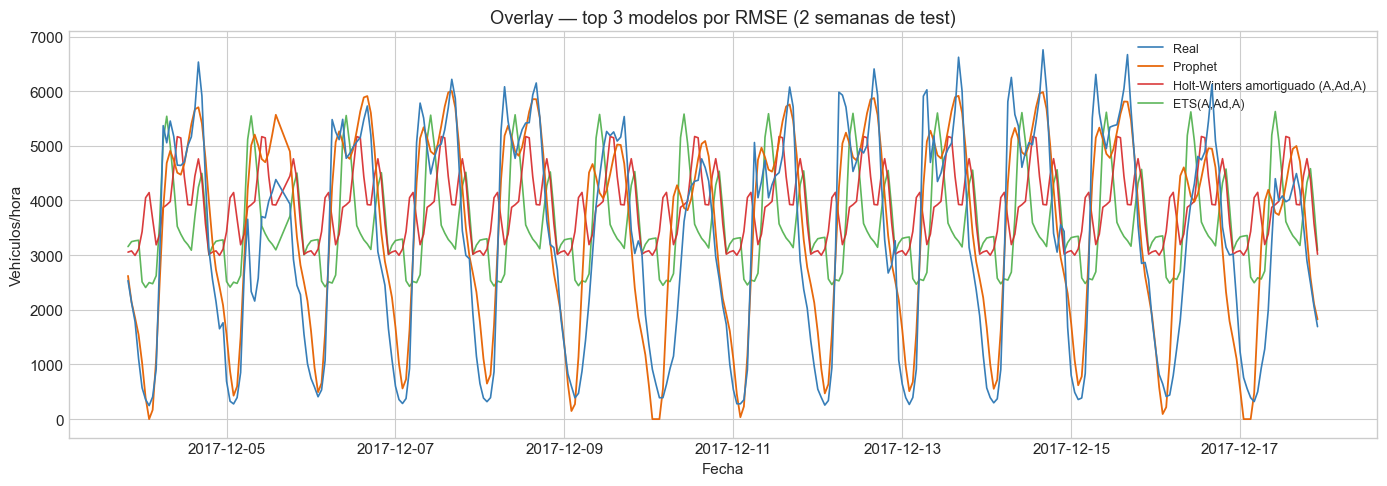

In [24]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

hw_damped = ExponentialSmoothing(
    y_train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated",
).fit(optimized=True)
hw_pred = pd.Series(hw_damped.forecast(len(y_test)).values, index=y_test.index)

ets_add = ETSModel(
    y_train,
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
).fit()
ets_pred = pd.Series(ets_add.forecast(len(y_test)).values, index=y_test.index)

sarima_label = f"SARIMA{final_order}x{final_seasonal_order}"
pred_map = {
    "Holt-Winters amortiguado (A,Ad,A)": hw_pred,
    "ETS(A,Ad,A)": ets_pred,
    sarima_label: sarima_pred,
    "SARIMAX": sarimax_pred,
    "Prophet": prophet_pred,
}

OVERLAY_STYLE = {
    "Prophet": {"color": "#E66100", "linewidth": 1.3, "alpha": 0.95, "zorder": 5},
    "Holt-Winters amortiguado (A,Ad,A)": {"color": "#D62728", "linewidth": 1.2, "alpha": 0.9, "zorder": 4},
    "ETS(A,Ad,A)": {"color": "#4DAF4A", "linewidth": 1.2, "alpha": 0.9, "zorder": 3},
    "SARIMAX": {"color": "#984EA3", "linewidth": 1.2, "alpha": 0.9, "zorder": 2},
}
OVERLAY_STYLE[sarima_label] = {"color": "#A65628", "linewidth": 1.2, "alpha": 0.9, "zorder": 2}
OVERLAY_FALLBACK = ["#F781BF", "#999999", "#17BECF"]

top3 = comparativa.head(3)["modelo"].tolist()
plot_h = 24 * 14
idx = y_test.index[:plot_h]

# Paleta fija y contrastante (colorblind-friendly); Real en azul (#377EB8), HW amortiguado en rojo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    idx,
    y_test.loc[idx],
    label="Real",
    color="#377EB8",
    linewidth=1.2,
    alpha=1.0,
    zorder=10,
)

for i, name in enumerate(top3):
    pred = pred_map.get(name)
    if pred is None:
        print(f"Overlay: sin pronóstico para '{name}'")
        continue
    style = OVERLAY_STYLE.get(name)
    if style is None:
        style = {
            "color": OVERLAY_FALLBACK[i % len(OVERLAY_FALLBACK)],
            "linewidth": 1.2,
            "alpha": 0.9,
            "zorder": 1,
        }
    ax.plot(
        idx,
        pred.loc[idx],
        label=name,
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"],
        zorder=style.get("zorder", 1),
    )

ax.set_title("Overlay — top 3 modelos por RMSE (2 semanas de test)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Vehículos/hora")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### Conclusiones (§4.6)

#### Por qué se hizo así
- La tabla numérica no muestra **forma** del error; el overlay visualiza si el modelo captura rush hour y fines de semana.

#### Qué significa
- Superponer curvas en el **mismo test** garantiza comparación visual justa.

#### Resultados
- Overlay 2 semanas: **Real** (azul), **Prophet** (naranja), **HW amortiguado** (rojo) y **ETS(A,Ad,A)** (verde) — top 3 por RMSE.

#### Qué significan
- **Prophet (naranja)** sigue la **amplitud y fase** diaria del tráfico real; tras recortar negativos, los valles tocan 0 en lugar de ir por debajo.
- **HW (rojo) y ETS (verde)** reproducen el patrón diario pero con **piso artificial ~2500–3000 veh/h** de noche, cuando el real (azul) cae a **~500** — principal driver del RMSE alto y MAPE inflado de estos modelos.
- En picos matutinos/vespertinos, HW/ETS alcanzan ~5000–5500 veh/h vs **~6500** del real (azul) — subestiman la hora pico.
- La brecha visual explica por qué Prophet (RMSE 884) domina frente a HW (1804) aunque ambos capturen la forma diaria.

## 4.7 - Análisis de errores por hora del día

Se descompone el error absoluto de **Prophet** (mejor global), **HW amortiguado** (mejor clásico por RMSE) y **SARIMAX** (mejor Box-Jenkins) por **hora del día** (0–23).

**Motivación:** verificar si el error se concentra en **rush hour** (7–9 h, 16–18 h) y comparar dónde gana cada enfoque.

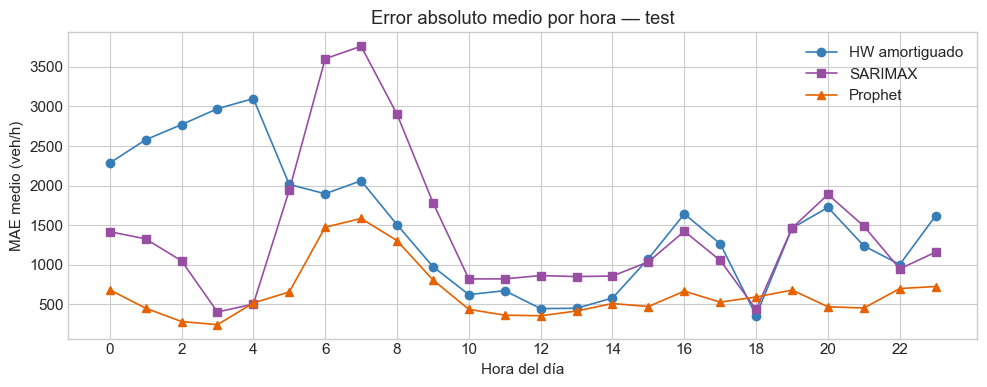

MAE medio rush [7, 8, 9, 16, 17, 18]: HW amortiguado=1303 | SARIMAX=1894 | Prophet=915
MAE medio resto: HW amortiguado=1585 | SARIMAX=1248 | Prophet=551


In [22]:
err_hw = np.abs(y_test.values - hw_pred.values)
err_sx = np.abs(y_test.values - sarimax_pred.values)
hours = y_test.index.hour

err_cols = {"MAE_HW": err_hw, "MAE_SARIMAX": err_sx}
if prophet_available and prophet_pred is not None:
    err_cols["MAE_Prophet"] = np.abs(y_test.values - prophet_pred.values)

err_by_hour = pd.DataFrame({"hour": hours, **err_cols}).groupby("hour").mean()

HOUR_STYLE = {
    "MAE_HW": {"color": "#377EB8", "marker": "o", "label": "HW amortiguado"},
    "MAE_SARIMAX": {"color": "#984EA3", "marker": "s", "label": "SARIMAX"},
    "MAE_Prophet": {"color": "#E66100", "marker": "^", "label": "Prophet"},
}

fig, ax = plt.subplots(figsize=(10, 4))
for col, style in HOUR_STYLE.items():
    if col in err_by_hour.columns:
        ax.plot(
            err_by_hour.index,
            err_by_hour[col],
            color=style["color"],
            marker=style["marker"],
            label=style["label"],
            linewidth=1.2,
        )

ax.set_xlabel("Hora del día")
ax.set_ylabel("MAE medio (veh/h)")
ax.set_title("Error absoluto medio por hora — test")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

peak_hours = [h for h in [7, 8, 9, 16, 17, 18] if h in err_by_hour.index]
off_peak = [h for h in err_by_hour.index if h not in peak_hours]

def _mean_mae(col, hours_idx):
    return err_by_hour.loc[hours_idx, col].mean()

summary_cols = [c for c in ("MAE_HW", "MAE_SARIMAX", "MAE_Prophet") if c in err_by_hour.columns]
rush_parts = " | ".join(f"{HOUR_STYLE[c]['label']}={_mean_mae(c, peak_hours):.0f}" for c in summary_cols)
rest_parts = " | ".join(f"{HOUR_STYLE[c]['label']}={_mean_mae(c, off_peak):.0f}" for c in summary_cols)
print(f"MAE medio rush {peak_hours}: {rush_parts}")
print(f"MAE medio resto: {rest_parts}")

### Conclusiones (§4.7)

#### Por qué se hizo así
- RMSE global **oculta** si fallamos más en horas punta; el TP menciona rush hour como patrón clave (NB1).

#### Qué significa
- MAE por hora = error medio cuando el reloj marca $h$ en test; picos altos en 7–9 y 16–18 indican mala captura del commute.

#### Resultados
- MAE medio **rush** (7–9, 16–18 h): HW **1303** | SARIMAX **1894** | Prophet **915** veh/h.
- MAE medio **resto**: HW **1585** | SARIMAX **1248** | Prophet **551** veh/h.
- Picos por hora: SARIMAX ~**3750** en h=7; HW ~**3100** en h=4; Prophet <**1600** en todo el día.

#### Qué significan
- **Prophet** domina en rush **y** fuera de punta — coherente con su RMSE global (884).
- **SARIMAX** falla en el **arranque del rush matutino** (h=7): peor que HW y mucho peor que Prophet.
- **HW** es débil en **madrugada (2–4 h)** pero más robusto que SARIMAX en commute agregado.
- Complementariedad HW vs SARIMAX: HW gana en rush promedio; SARIMAX gana en valle — pero ninguno compite con Prophet hora a hora.
- El pico de SARIMAX en h=7 explica por qué tiene el **mejor MAE clásico** (1411) pero **peor RMSE** que HW (1855 vs 1804): RMSE penaliza outliers como el error de las 7 h.

## 4.8 - Conclusiones globales del TP

### Conclusiones (§4.8)

#### Respuesta a la pregunta de investigación

**1. ¿Qué modelo clásico pronostica mejor?**  
Entre modelos **clásicos** (ETS, Holt-Winters, SARIMA/SARIMAX): **Holt-Winters amortiguado (A,Ad,A)** con RMSE **1803.7** veh/h. Le siguen ETS(A,Ad,A) (1848.2) y SARIMAX (1854.8). SARIMA$(2,1,2)(1,1,1)_{24}$ queda en 1898.5.  
**Matiz MAE:** SARIMAX tiene el **mejor MAE clásico** (1410.9), pero RMSE peor que HW por errores extremos en h=7 (§4.7).

**Benchmark alternativo:** **Prophet** alcanza RMSE **884.4** y MAE **642.3** — mucho menor que cualquier clásico. Estacionalidad diaria + semanal + anual flexible; no responde la pregunta de clima (sin exógenas).

**2. ¿Las exógenas mejoran frente a SARIMA univariado?**  
**Sí:** SARIMAX reduce RMSE de **1898.5** a **1854.8** (~44 veh/h) y MAE de 1489 a 1411. Lluvia significativa (−0,26 mm⁻¹ en NB3).  
**Pero:** SARIMAX **no supera** HW/ETS en RMSE; clima aporta señal **incremental** dentro de Box-Jenkins.

**Análisis horario (§4.7):** Prophet reduce error en todo el día; SARIMAX colapsa en h=7; HW falla en madrugada. El overlay (§4.6) muestra que HW/ETS no capturan el valle nocturno (~500 veh/h real vs ~2500–3000 pronosticados).

**Diagnóstico de varianza:** ARCH-LM $p \approx 0$ → GARCH(1,1) con $\alpha+\beta \approx 0{,}98$ (volatilidad persistente en residuos SARIMAX; no mejora la media).

#### Decisiones metodológicas clave (hilo del TP)
| Decisión | Por qué | Resultado |
|----------|---------|----------|
| $(1,1,1)(1,1,1)_{24}$ inicial (NB2) | ACF/PACF + ADF | Punto de partida razonable |
| Grid → $(2,1,2)(1,1,1)_{24}$ (NB3) | BIC en train completo | Más memoria AR/MA regular |
| Exógenas temp/rain/snow/holiday | Pregunta central TP | SARIMAX mejora SARIMA; feriado n.s. |
| Test = 4 semanas | Plan fijo | 672 h comparables |
| Prophet (NB4) | Baseline alternativo | RMSE 884.4 — mejor global |
| Recorte Prophet ≥ 0 | Tráfico no negativo | 18 h recortadas en test |
| ARCH/GARCH (NB4) | Heteroscedasticidad residuos | ARCH-LM sig.; GARCH(1,1) persistente |

#### Limitaciones (para informe)
- Una autopista, subperiodo 2016–2017, ~993 huecos horarios imputados (NB1).
- Exógenas **observadas** en test (backtest optimista).
- SARIMA/HW con $s=24$ no modelan estacionalidad **semanal** explícita (Prophet sí).
- MAPE distorsionado con volúmenes nocturnos bajos (HW 170%) — preferir MAE/RMSE.
- Recorte de Prophet a 0 en 18 horas de test (artefacto del modelo aditivo).
- Residuos SARIMAX no pasan Ljung-Box ($p \approx 0$) — diagnóstico imperfecto.
- Prophet no es “clásico”; comparar interpretaciones con cautela.
- LSTM omitido (§4.9).

#### Próximo paso
- Redactar `informe.md` con tabla `comparativa_final.csv`, figuras de overlay (§4.6) y error por hora (§4.7), y respuesta explícita a las dos preguntas.

## 4.9 - LSTM (opcional — omitido)

Según el plan del TP, un **LSTM** con ventana deslizante es **apéndice opcional** (solo si sobra tiempo).

**Estado:** omitido en esta entrega para priorizar baselines clásicos + SARIMA/SARIMAX + Prophet + informe.

**Si se implementara:** ventana de 24–168 h, mismo split train/test, comparar MAE/RMSE con SARIMAX; requeriría escalado, semilla fija y GPU opcional.

**Cierre Notebook 4:**

- [x] Métricas NB2+NB3 consolidadas (5 modelos principales)
- [x] Prophet ejecutado (RMSE 884.4; 18 negativos recortados)
- [x] ARCH-LM sobre residuos SARIMAX ($p \approx 0$)
- [x] GARCH(1,1) ajustado ($\alpha+\beta \approx 0{,}98$)
- [x] `comparativa_final.csv` exportado (sin baselines NB2)
- [x] Overlay top 3 y análisis de error por hora (Prophet incluido)
- [x] Conclusiones globales §4.8 alineadas con outputs y gráficos